# SIR simulation in a grid

Simulate parameters from a specific range. Plot the pairs of simulated parameters in a grid. Plot also the "density" representing the distance measure (likelihood approximation from [Lintusaari et al 2016](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC4788128/ )).


Ranges for $\beta$, $\gamma$ (from Lintusaari et al 2016)
- $\beta = [0.3, 2]$
- $\gamma = [0.0125, 1.5]$
 - NOTE: these are not the birth and death rates as in a birth-death process. These are the transmission coefficient and the recovery rate of an SIR model. The ranges from Lintusaari et al 2016 are probably not directly applicable here.
 

Approximate likelihood function:

$$\hat{L}(\theta) \propto \frac{1}{N}\sum_{i = 1}^N1_{[0,\epsilon]}[d(a^*, a)]$$


Design choices: distance function, threshold, summaries, range of $\beta$ and $\gamma$

**TODO**
 - Simulation parameters DONE
 - Fix observational model 

**Questions**
- Should the grid be evenly spaced? Should I only simulate at these evenly spaced points?
- Is this a type of maximum likelihood estimation?
- How to choose epsilon?


**Sources**
- On the identifiability of transmission dynamic models for infectious disease: https://www.ncbi.nlm.nih.gov/pmc/articles/PMC4788128/ 




In [33]:
import numpy as np
import matplotlib.pyplot as plt
from cluster.scripts.load_data import * # import data: odds ratios, BSI...

In [34]:
# Step 1: Approximation of the likelihood function


def approx_likelihood(dist, epsilon=0.0001):
    # Calculates the approximate likelihood over N simulations for a given parameter pair
    # dist: distances between the simulated and observed sequences over N simulations
    
    N = dist.shape[0]
    lik = 0
    for d in dist:
        #print(d)
        
        if d < epsilon:
            lik += d
    
    return 1/N*lik

    
# Distance function

# TODO: add summaries here 
def BSI_max_t(y):
    # time to peak/maximum number of bsi cases
    
    return np.argmax(y)

def BSI_max(y):
    # maximum number of BSI cases
    
    max_bsi = np.max(y)
    
    return max_bsi#.reshape(-1,1).transpose()

def distance(sim, obs, S1_fun, S2_fun):
    # Euclidean distance between the simulated and observed sequence
    # d(a*, a) where a* is the observed sequence and a is the simulated sequence
    # sim: simulated sequence
    # obs: observed sequence
    # S1_fun, S2_fun: summary functions that return a scalar summary based on the input sequence
    
    S1_obs = S1_fun(obs)
    S2_obs = S2_fun(obs)
    
    S1_sim = S1_fun(sim)
    S2_sim = S2_fun(sim)
    
    # TODO: add weigthing with standard deviation of S1 and S2 over some amount of simulation
    return np.sqrt((S1_sim - S1_obs)**2 + (S2_sim - S2_obs)**2)


def distance_generalized(y_sim, y_obs, sum_func): # TODO: sum_func as args
    # Allow more than 2 summaries
    # sum_func: summary functions of interest in a list
    # y_sim: simulated sequence
    # y_obs: observed sequence
    
    dist = 0
    
    for i in range(0, len(sum_func)):
        summary = sum_func[i]
        dist += (summary(y_sim) - summary(y_obs))**2

    return np.sqrt(dist)


In [35]:
y_obs = np.array([1,2,3,4,5])
y_sim = np.array([1.2, 3.4, 3.9, 6.2])


distance_generalized(y_sim, y_obs, [np.mean])

0.6749999999999998

In [37]:
# Step 2: Simulation function, observed data (import from file)

import importlib
import cluster.scripts.BSI_functions
importlib.reload(cluster.scripts.BSI_functions) # for changes to take effect

from cluster.scripts.BSI_functions import *

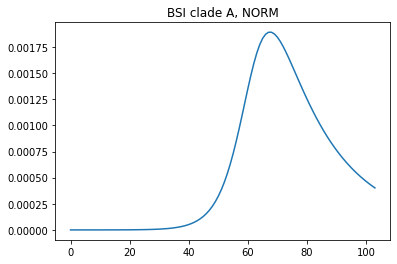

In [133]:
# Observed data:

# First, synthetic data:

pop_size = 100000
n_weeks = 104
clade = "A"

bsi_pars = {"or_data": or_data, "clade": clade, "dataset": "NORM", "theta_c":1, "theta_bsi":0.3}
bsi_obs = SIR_and_BSI_simulator(np.array([0.256]), np.array([0.045]), nt = n_weeks, N = pop_size,\
                                bsi_pars = bsi_pars, is_prop = True,\
                                is_agg = False, time_period = 52, batch_size = 1, random_state = None)#.flatten()
 
# Plot the synthetic observed data:
plt.plot(bsi_obs[0])
dataset = bsi_pars["dataset"]
plt.title(f"BSI clade {clade}, {dataset}")

plt.show()

In [134]:
# Step 3: Running the simulation over pairs of parameters and get the approximate likelihood

# Pick parameters for the simulation

# dimensions of the grid to simulate
n_beta = 50
n_gamma = 40

N_sim = 100 # number of simulations at each point in the grid
e = 0.01 # epsilon, large enough epsilon means that all distances will be in the grid

beta_range = (0.5, 1.5) # range of beta values to simulate
gamma_range = (0.0125, 0.1) # range of gamma values to simulate

def approx_likelihood_grid(beta_range, gamma_range, n_beta, n_gamma, N_sim, e, bsi_obs):
    betas = np.linspace(beta_range[0], beta_range[1], n_beta)
    gammas = np.linspace(gamma_range[0], gamma_range[1], n_gamma)

    approx_lik_mat= np.zeros((n_beta, n_gamma))
    iters = 0
    for i in range(0, n_beta):
        for j in range(0, n_gamma):

            if iters%100 == 0:
                print("Iter:", iters)
            beta = betas[i]
            gamma = gammas[j]

            distances = np.zeros(N_sim)

            for h in range(0, N_sim):
                sim_seq = SIR_and_BSI_simulator(beta, gamma, n_weeks, pop_size, bsi_pars,\
                                  is_prop = True, is_agg = False, time_period = 52, reparam = False,\
                                  batch_size = 1, random_state = None)[0]
                distances[h] = distance(sim_seq, bsi_obs, BSI_max, BSI_max_t)

            # Calculate the approximate likelihood for this parameter pair:

            L_hat = approx_likelihood(distances, epsilon=e)
            if not isinstance(L_hat, float):
                print(f"Warning! Not float. Iter {iters}.")
                print(L_hat)
                print(f"Parameter pair: {beta}, {gamma}")
            else:
                approx_lik_mat[i,j] = L_hat

            iters += 1
    
    return approx_lik_mat, betas, gammas

#approx_lik_mat, betas, gammas = approx_likelihood_grid(beta_range, gamma_range, n_beta, n_gamma, N_sim, e, bsi_obs[0])

In [135]:
# Step 5: Visualize the approximate likelihood over the grid of parameters

#print(approx_lik_mat.shape) # (n_betas, n_gammas)

In [136]:
def hide_ticks(ax_get_tick_labels, nth):
    # Based on: https://stackoverflow.com/questions/6682784/reducing-number-of-plot-ticks
    # ax_get_tick_labels: ax.xaxis.get_ticklabels() or ax.yaxis.get_ticklabels()
    # nth: which labels are shown?
    
    for n, label in enumerate(ax_get_tick_labels):
        if n % nth != 0:
            label.set_visible(False)
    

In [137]:
def plot_heatmap(mat, betas, gammas, title, cbar_label, nth = 4):
    # mat: matrix of interest, approximate likelihoods or distances for example
    # betas: row labels (parameter values at the row)
    # gammas: col labels (parameter values)
    # title: title of the plot
    # cbar_label: color bar label
    # nth: how "manyeth" tick label is displayed
    
    fig, ax = plt.subplots(figsize=(10, 10))

    row_labels = np.round(betas, 2)
    col_labels = np.round(gammas,2)

    im = ax.imshow(mat)
    ax.set_yticks(np.arange(mat.shape[0]), labels=row_labels)
    ax.set_xticks(np.arange(mat.shape[1]), labels=col_labels, rotation = 45)
    ax.set_xlabel("Gamma")
    ax.set_ylabel("Beta")
    
    cbar = ax.figure.colorbar(im, ax=ax)
    cbar.ax.set_ylabel(cbar_label, rotation=-90, va="bottom")
    ax.set_title(title)

    hide_ticks(ax.xaxis.get_ticklabels(), nth = nth)
    hide_ticks(ax.yaxis.get_ticklabels(), nth = nth)

    plt.show()

In [138]:
#plot_heatmap(approx_lik_mat, betas, gammas, f"Approx likelihood, epsilon {e}", "Approximate likelihood")

Gammatx-akselilla, betat y-akselilla tässä.

## Distance between observed and simulated sequence summaries at $\beta, \gamma$

Do not calculate the likelihood but rather the distance between observed and simulated summaries at a given data pair directly.

Scaling: 

$D_{scaled} = \sqrt{\sum_{i = 1}^N\frac{1}{SD(d_i)}d_i},$

where $N$ is the number of summaries and $d_i = (S_{i,obs} - S_{i,sim})^2$. $S_i$ is the summary of interest.

In [139]:
300*300


90000

In [146]:
# dimensions of the grid to simulate
n_beta = 300
n_gamma = 300

beta_range = (0.1, 1.0) # range of beta values to simulate
gamma_range = (0.0125, 0.1) # range of gamma values to simulate

def test_beta_and_gamma(beta, gamma):
    # returns False for the pair beta, gamma if they do not create an epidemic or R0 > 8.
    # returns True if beta/gamma is within the allowed range
    
    if beta/gamma <= 1:
        #print("No epidemic. Disregard this combo.")
        return False
        
    if beta/gamma > 8:
        #print("Infeasible parameters, R0 > 8.")
        return False

    return True

def get_distance_grid(beta_range, gamma_range, n_beta, n_gamma, dist_func, summaries, bsi_obs, is_agg = False, scale = True):
    # Get the distance between pairs of gamma and beta in the given range
    
    betas = np.linspace(beta_range[0], beta_range[1], n_beta)
    gammas = np.linspace(gamma_range[0], gamma_range[1], n_gamma)

    # Save the squared differences between true and simulated summaries
    #delta_S1_mat = np.zeros((n_beta, n_gamma))
    #delta_S2_mat = np.zeros((n_beta, n_gamma))
    
    summary_mat = np.zeros((n_beta, n_gamma, len(summaries)))
    #summary_mat.fill(2)
    summary_mat.fill(np.nan)
    
    dist_mat = np.zeros((n_beta, n_gamma))
    #dist_mat.fill(10)
    #dist_mat = np.empty((n_beta, n_gamma))
    dist_mat.fill(np.nan)
    
    iters = 0

    for i in range(0, n_beta):
        for j in range(0, n_gamma):

            if iters%1000 == 0:
                print("Iter:", iters)
                
            beta = betas[i]
            gamma = gammas[j]
            
            if test_beta_and_gamma(beta, gamma):

                sim_seq = SIR_and_BSI_simulator(beta, gamma, n_weeks, pop_size, bsi_pars,\
                                      is_prop = True, is_agg = is_agg, time_period = 52, reparam = False,\
                                      batch_size = 1, random_state = None)[0]

                k = 0
                for summary in summaries:
                    summary_mat[i,j,k] = (summary(bsi_obs) - summary(sim_seq))**2 # to be fair, this is a distance matrix for a summary, not a summary matrix
                    k += 1
                
            #delta_S1_mat[i,j] = (BSI_max(bsi_obs) - BSI_max(sim_seq))**2
            #delta_S2_mat[i,j] = (BSI_max_t(bsi_obs) - BSI_max_t(sim_seq))**2
            
                dist = dist_func(sim_seq, bsi_obs, summaries) # redundant? unless not using scaling

                if not isinstance(dist, float):
                    print(f"Warning! Not float. Iter {iters}.")
                    print(dist)
                    print(f"Parameter pair: {beta}, {gamma}")
                else:
                    dist_mat[i,j] = dist

            iters += 1
            
    if scale:
        
        summary_mat = np.ma.array(summary_mat, mask = np.isnan(summary_mat)) # mask the nan values so that np.std does not return nans
        
        SD1 = np.std(summary_mat[:,:,0])
        
        dist_mat = 1/SD1*summary_mat[:,:,0]
        
        for k in range(1, len(summaries)):
            
            SD = np.std(summary_mat[:,:,k])
            
            if SD == 0:
                print("Warning! SD is zero. Summary index:", k)
                SD = 1 # TODO: what to do in this case? 
                
            dist_mat += 1/SD*summary_mat[:,:,k]
            
        dist_mat = np.sqrt(dist_mat)
    
    #return dist_mat, betas, gammas, delta_S1_mat, delta_S2_mat# return betas and gammas for plotting purposes
    
    return dist_mat, betas, gammas, summary_mat

In [147]:
dist_mat, betas, gammas, summary_mat = get_distance_grid(beta_range, gamma_range, n_beta, n_gamma,\
                                                         distance_generalized, [BSI_max, BSI_max_t], bsi_obs[0])
#dist_mat, betas, gammas, summary_mat = get_distance_grid(beta_range, gamma_range, n_beta, n_gamma, bsi_obs[0])

Iter: 0
Iter: 1000
Iter: 2000
Iter: 3000
Iter: 4000
Iter: 5000
Iter: 6000
Iter: 7000
Iter: 8000
Iter: 9000
Iter: 10000
Iter: 11000
Iter: 12000
Iter: 13000
Iter: 14000
Iter: 15000
Iter: 16000
Iter: 17000
Iter: 18000
Iter: 19000
Iter: 20000
Iter: 21000
Iter: 22000
Iter: 23000
Iter: 24000
Iter: 25000
Iter: 26000
Iter: 27000
Iter: 28000
Iter: 29000
Iter: 30000
Iter: 31000
Iter: 32000
Iter: 33000
Iter: 34000
Iter: 35000
Iter: 36000
Iter: 37000
Iter: 38000
Iter: 39000
Iter: 40000
Iter: 41000
Iter: 42000
Iter: 43000
Iter: 44000
Iter: 45000
Iter: 46000
Iter: 47000
Iter: 48000
Iter: 49000
Iter: 50000
Iter: 51000
Iter: 52000
Iter: 53000
Iter: 54000
Iter: 55000
Iter: 56000
Iter: 57000
Iter: 58000
Iter: 59000
Iter: 60000
Iter: 61000
Iter: 62000
Iter: 63000
Iter: 64000
Iter: 65000
Iter: 66000
Iter: 67000
Iter: 68000
Iter: 69000
Iter: 70000
Iter: 71000
Iter: 72000
Iter: 73000
Iter: 74000
Iter: 75000
Iter: 76000
Iter: 77000
Iter: 78000
Iter: 79000
Iter: 80000
Iter: 81000
Iter: 82000
Iter: 83000
Iter:

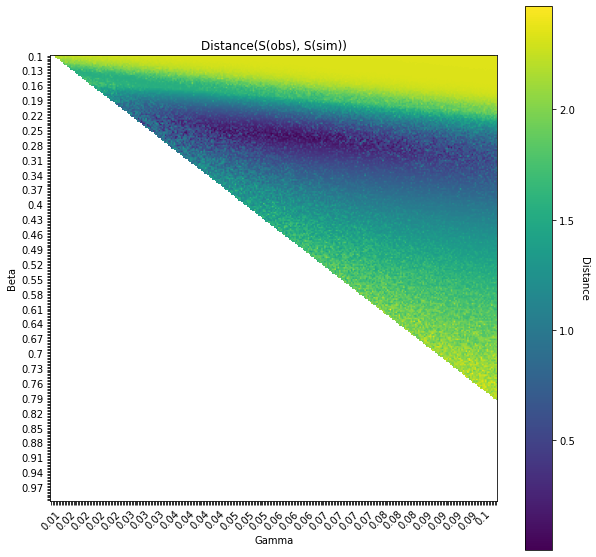

In [148]:
plot_heatmap(dist_mat, betas, gammas, title = "Distance(S(obs), S(sim))", cbar_label = "Distance", nth = 10) # synthetic observed data

# Q: what happens to the BSI_max summary?
# TODO: better alternative is to sample from a range of beta, gamma values that is always ok.

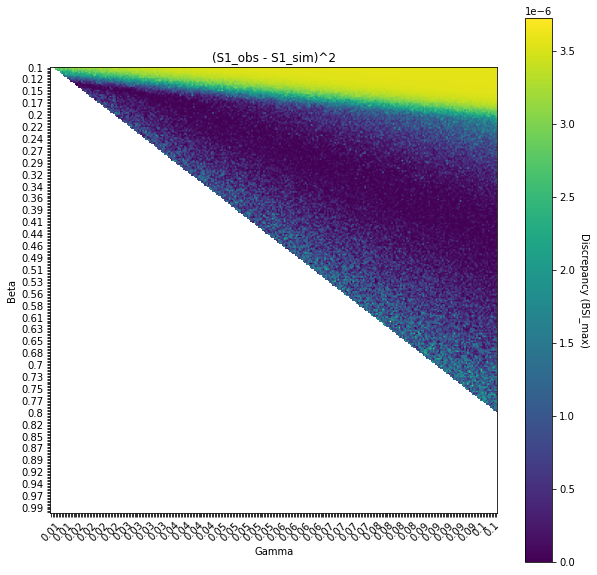

In [149]:
plot_heatmap(summary_mat[:,:,0], betas, gammas, title = "(S1_obs - S1_sim)^2", cbar_label = "Discrepancy (BSI_max)", nth = 8)
# Works, if I set summary_mat to nan. Probably a scaling issue if I set it to anything else.

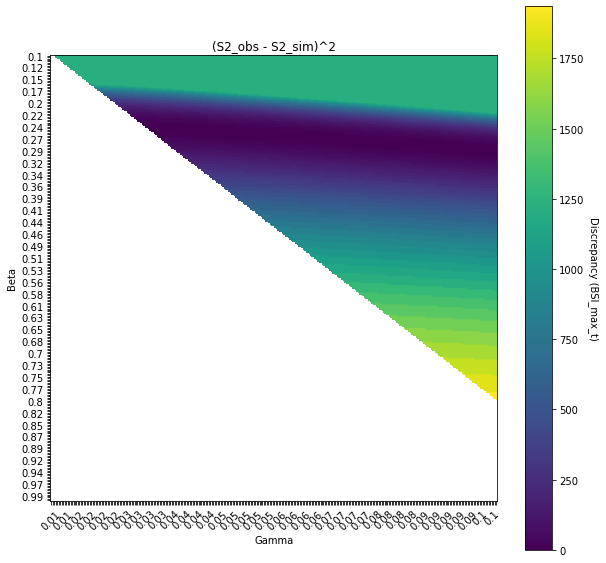

In [150]:
plot_heatmap(summary_mat[:,:,1], betas, gammas, title = "(S2_obs - S2_sim)^2", cbar_label = "Discrepancy (BSI_max_t)", nth = 8)

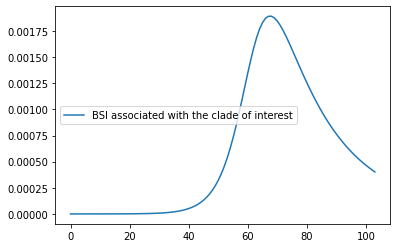

In [151]:
# Plot BSI observations

plot_BSI(bsi_obs)


In [50]:

def BSI_var(y):
    
    return np.var(y)

def BSI_t0(y):
    # Time from the beginning of the epidemic (first nonzero value in BSI, with some tolerance) to the peak of the epidemic
    # How this works: compare consecutive values. If the difference between these values is larger than a given treshold, 
    # return the current index. This is where the "peak" starts and can be used as a summary statistic.
    # Alternative: input the start of the epidemic manually, assuming it is known (this is the case with true observed data
    # bsi_obs: a numpy array containing the observed proportion of BSI cases. NOTE: not in batches!!
    
    tres = np.var(y)

    for i in range(0, len(y) - 1):
        j = i + 1 # index of the next value in the observed sequence
        diff = y[j] - y[i]

        if diff > tres:
            break # we'll start at the first found index

    
    return i # start from this index (year/week)


def BSI_delta_t(bsi_obs, t0 = None):
    # Find the time difference between t0 (start of peak) and the peak of BSI cases.
    # t0: can input a value for t0 manually. 
    # This statistic is obsolete if the observed data starts from the beginning of the peak. Then t0 would be 0.
    
    if t0 == None:
        t0 = BSI_t0(bsi_obs)
    t_max = BSI_max_t(bsi_obs)
    
    if t0 > t_max:
        #print("BSI_delta_t: t0 > t_max!")
        #print(t0, t_max)
        #print(bsi_obs)
        return 0
    
    return t_max - t0
    
def BSI_k(bsi_obs, t0 = None, t1 = None):
    # Get the slope between t0 and t1
    # If t1 is None, use the half point between t_max and t0 as a default
    # (But this is essentially just a combination of t_max and BSI_max)
    
    t_max = BSI_max_t(bsi_obs)
    
    if t0 == None:
        # use the start of the peak as t0
        t0 = BSI_t0(bsi_obs)
     
    if t1 == None:
        t1 = int((t_max - t0)/2)

    if t1 > t_max:
        print("warning! t1 is larger than t_max! Using t_max")
        t1 = t_max


    k = (t1 - t0)/(bsi_obs[t1] - bsi_obs[t0])

    return k




In [51]:
BSI_t0(bsi_obs[0])

8

In [52]:
BSI_max_t(bsi_obs[0])

25

In [53]:
BSI_delta_t(bsi_obs[0])

17

In [54]:
# testing: 
print(BSI_k(bsi_obs[0]))
BSI_k(bsi_obs[0], 0, 30)

nan
warning! t1 is larger than t_max! Using t_max


<ipython-input-50-ee0dc1781290>:61: RuntimeWarning: invalid value encountered in double_scalars
  k = (t1 - t0)/(bsi_obs[t1] - bsi_obs[t0])


5179.623211519995

In [ ]:
# Using the new t0 summary statistic:
dist_mat, betas, gammas, summary_mat = get_distance_grid(beta_range, gamma_range, n_beta, n_gamma,\
                                                         distance_generalized, [BSI_max, BSI_max_t, BSI_delta_t, BSI_k, BSI_var], bsi_obs[0])

In [ ]:
plot_heatmap(summary_mat[:,:,0], betas, gammas, title = "(S2_obs - S2_sim)^2", cbar_label = "Discrepancy (BSI_max)", nth = 8)
plot_heatmap(summary_mat[:,:,1], betas, gammas, title = "(S2_obs - S2_sim)^2", cbar_label = "Discrepancy (BSI_max_t)", nth = 8)
plot_heatmap(summary_mat[:,:,2], betas, gammas, title = "(S2_obs - S2_sim)^2", cbar_label = "Discrepancy (BSI_delta_t)", nth = 8)
plot_heatmap(summary_mat[:,:,3], betas, gammas, title = "(S2_obs - S2_sim)^2", cbar_label = "Discrepancy (BSI_k)", nth = 8)
plot_heatmap(summary_mat[:,:,4], betas, gammas, title = "(S2_obs - S2_sim)^2", cbar_label = "Discrepancy (BSI_var)", nth = 8)
#plot_heatmap(summary_mat[:,:,5], betas, gammas, title = "(S2_obs - S2_sim)^2", cbar_label = "Discrepancy (BSI_t0)", nth = 8)

# TODO: test variance!


In [ ]:
# Distance matrix
plot_heatmap(dist_mat, betas, gammas, title = "Distance(S(obs), S(sim))", cbar_label = "Distance", nth = 8) # synthetic observed data

In [ ]:
# TODO: plot/print some summaries given the parameters of interest. More interesting for real data.
# TODO: plot the actual summary values in some range? Additional functionality.
# TODO: save values of summaries with a small distance (below some threshold, maybe under 0.25 (based on the colorbar)


print("Observed summaries from (synthetic) data:")
print("BSI maximum:", BSI_max(bsi_obs))
print("Time to max peak:", BSI_max_t(bsi_obs))
print("t0:", BSI_t0(bsi_obs))
print("BSI_k:", BSI_k(bsi_obs[0]))
print("BSI_delta_t:", BSI_delta_t(bsi_obs[0])) # -15???

In [ ]:
def plot_histograms(dist_mat, eps):  
    # eps: tolerance. Plot parameter values with distance under this value
    
    fig, axs = plt.subplots(1, 2)
    axs[0].hist(betas[np.where(dist_mat < eps)[0]])
    axs[1].hist(gammas[np.where(dist_mat < eps)[1]])
    axs[0].set_xlabel("Gamma")
    axs[1].set_xlabel("Beta")
    axs[0].set_title(f"Tolerance: {eps}")
    plt.show()

# Observations:
# - Increasing tolerance increases uncertainty in the estimated parameters.
# - Did not find outliers.
# - Random idea: separate tolerances for gamma and beta?

plot_histograms(dist_mat, 0.25)
plot_histograms(dist_mat, 0.5)
plot_histograms(dist_mat, 1)

### Potential issues

- Different scales on the y and x axis might impact the distance calculation - is the same treshold applicaple to both parameters? Should some standardization/normalization happen here?

# Distance matrix between synthetic aggregated data and simulations

Identifiability of aggregated synthetic data.

TODO: Use the reparametrized version: net transmission rate and R.
- Or alternatively, limit $\frac{\beta}{\gamma}$ to be between 1 and 8(10). A custom prior?


In [66]:
0.256/0.045

5.688888888888889

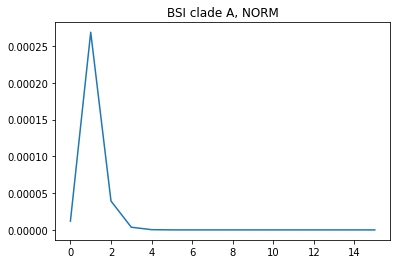

In [57]:
# Synthetic aggregated data:

pop_size = 100000
n_weeks = 832
clade = "A"

bsi_pars = {"or_data": or_data, "clade": clade, "dataset": "NORM", "theta_c":1, "theta_bsi":0.001}
bsi_obs_agg = SIR_and_BSI_simulator(np.array([0.256]), np.array([0.045]), nt = n_weeks, N = pop_size,\
                                bsi_pars = bsi_pars, is_prop = True,\
                                is_agg = True, time_period = 52, batch_size = 1, random_state = None)#.flatten()
 
# Plot the synthetic observed data:
plt.plot(bsi_obs_agg[0])
dataset = bsi_pars["dataset"]
plt.title(f"BSI clade {clade}, {dataset}")

plt.show()

# dimensions of the grid to simulate
n_beta = 100
n_gamma = 90

beta_range = (0.05, 1.5) # range of beta values to simulate
gamma_range = (0.0125, 0.1) # range of gamma values to simulate

# Potential issue: resolution of the grid too low? Too large jumps between pairs of parameters?


# Prop. 350%????

In [58]:
dist_mat, betas, gammas, summary_mat = get_distance_grid(beta_range, gamma_range, n_beta, n_gamma,\
                                                         distance_generalized, [BSI_max, BSI_max_t], bsi_obs_agg[0], is_agg = True)

Iter: 0
Iter: 200
Iter: 400
Iter: 600
Iter: 800
Iter: 1000
Iter: 1200
Iter: 1400
Iter: 1600
Iter: 1800
Iter: 2000
Iter: 2200
Iter: 2400
Iter: 2600
Iter: 2800
Iter: 3000
Iter: 3200
Iter: 3400
Iter: 3600
Iter: 3800
Iter: 4000
Iter: 4200
Iter: 4400
Iter: 4600
Iter: 4800
Iter: 5000
Iter: 5200
Iter: 5400
Iter: 5600
Iter: 5800
Iter: 6000
Iter: 6200
Iter: 6400
Iter: 6600
Iter: 6800
Iter: 7000
Iter: 7200
Iter: 7400
Iter: 7600
Iter: 7800
Iter: 8000
Iter: 8200
Iter: 8400
Iter: 8600
Iter: 8800


In [76]:
# Check for infeasible combos of beta and gamma:
bad_combos = []
for i in range(0, len(betas)):
    for j in range(0, len(gammas)):
        if not test_beta_and_gamma(betas[i], gammas[j]):
            bad_combos.append((betas[i], gammas[j]))
       
print(f"Simulated {i*j} pairs of parameters, {len(bad_combos)} of which were not within 1 < R0 < 8.") # ah. explains things.

Simulated 8811 pairs of parameters, 6612 of which were not within 1 < R0 < 8.


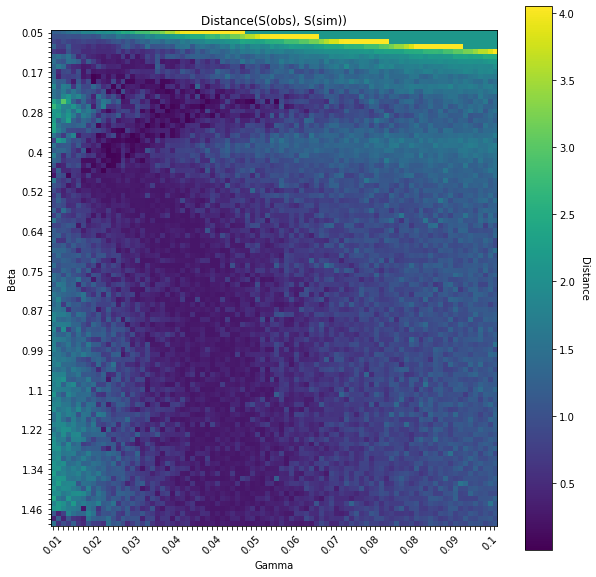

In [59]:
plot_heatmap(dist_mat, betas, gammas, title = "Distance(S(obs), S(sim))", cbar_label = "Distance", nth = 8) # synthetic observed data, aggregated

### Check: same true parameters, not aggregated

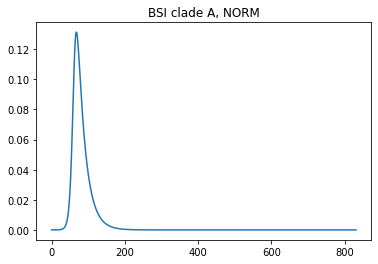

In [29]:
pop_size = 100000
n_weeks = 832
clade = "A"

bsi_pars = {"or_data": or_data, "clade": clade, "dataset": "NORM", "theta_c":1, "theta_bsi":0.3}
bsi_obs = SIR_and_BSI_simulator(np.array([0.256]), np.array([0.045]), nt = n_weeks, N = pop_size,\
                                bsi_pars = bsi_pars, is_prop = True,\
                                is_agg = False, time_period = 52, batch_size = 1, random_state = None)#.flatten()
 
# Plot the synthetic observed data:
plt.plot(bsi_obs[0])
dataset = bsi_pars["dataset"]
plt.title(f"BSI clade {clade}, {dataset}")

plt.show()

# dimensions of the grid to simulate
n_beta = 100
n_gamma = 90

beta_range = (0.05, 1.5) # range of beta values to simulate
gamma_range = (0.0125, 0.1) # range of gamma values to simulate

Iter: 0
Iter: 200
Iter: 400
Iter: 600
Iter: 800
Iter: 1000
Iter: 1200
Iter: 1400
Iter: 1600
Iter: 1800
Iter: 2000
Iter: 2200
Iter: 2400
Iter: 2600
Iter: 2800
Iter: 3000
Iter: 3200
Iter: 3400
Iter: 3600
Iter: 3800
Iter: 4000
Iter: 4200
Iter: 4400
Iter: 4600
Iter: 4800
Iter: 5000
Iter: 5200
Iter: 5400
Iter: 5600
Iter: 5800
Iter: 6000
Iter: 6200
Iter: 6400
Iter: 6600
Iter: 6800
Iter: 7000
Iter: 7200
Iter: 7400
Iter: 7600
Iter: 7800
Iter: 8000
Iter: 8200
Iter: 8400
Iter: 8600
Iter: 8800


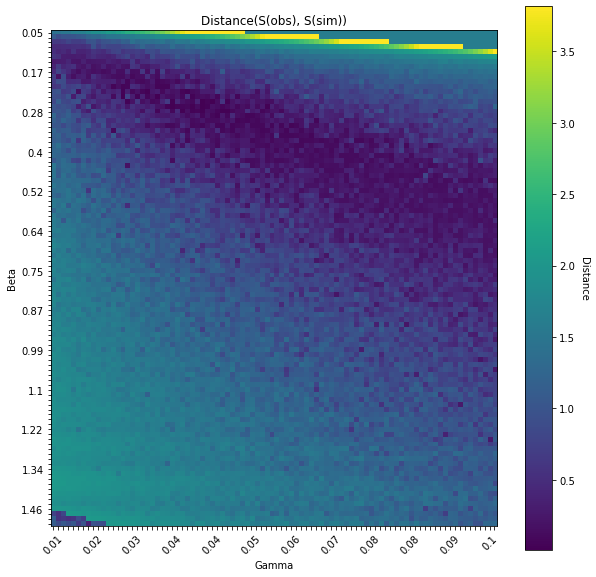

In [30]:
dist_mat, betas, gammas, summary_mat = get_distance_grid(beta_range, gamma_range, n_beta, n_gamma,\
                                                         distance_generalized, [BSI_max, BSI_max_t], bsi_obs[0], is_agg = False)

plot_heatmap(dist_mat, betas, gammas, title = "Distance(S(obs), S(sim))", cbar_label = "Distance", nth = 8) # synthetic observed data, aggregated


### Check: the parameter combo I know works, does it work for a longer period of time?

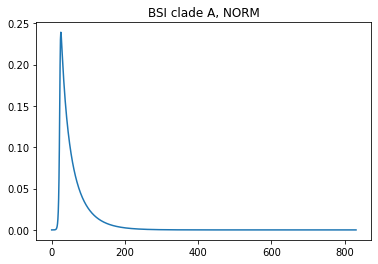

In [32]:
pop_size = 100000
n_weeks = 832
clade = "A"

bsi_pars = {"or_data": or_data, "clade": clade, "dataset": "NORM", "theta_c":1, "theta_bsi":0.3}
bsi_obs = SIR_and_BSI_simulator(np.array([0.735]), np.array([0.0223]), nt = n_weeks, N = pop_size,\
                                bsi_pars = bsi_pars, is_prop = True,\
                                is_agg = False, time_period = 52, batch_size = 1, random_state = None)#.flatten()
 
# Plot the synthetic observed data:
plt.plot(bsi_obs[0])
dataset = bsi_pars["dataset"]
plt.title(f"BSI clade {clade}, {dataset}")

plt.show()

# dimensions of the grid to simulate
n_beta = 100
n_gamma = 90

beta_range = (0.5, 1.5) # range of beta values to simulate
gamma_range = (0.0125, 0.1) # range of gamma values to simulate

Iter: 0
Iter: 200
Iter: 400
Iter: 600
Iter: 800
Iter: 1000
Iter: 1200
Iter: 1400
Iter: 1600
Iter: 1800
Iter: 2000
Iter: 2200
Iter: 2400
Iter: 2600
Iter: 2800
Iter: 3000
Iter: 3200
Iter: 3400
Iter: 3600
Iter: 3800
Iter: 4000
Iter: 4200
Iter: 4400
Iter: 4600
Iter: 4800
Iter: 5000
Iter: 5200
Iter: 5400
Iter: 5600
Iter: 5800
Iter: 6000
Iter: 6200
Iter: 6400
Iter: 6600
Iter: 6800
Iter: 7000
Iter: 7200
Iter: 7400
Iter: 7600
Iter: 7800
Iter: 8000
Iter: 8200
Iter: 8400
Iter: 8600
Iter: 8800


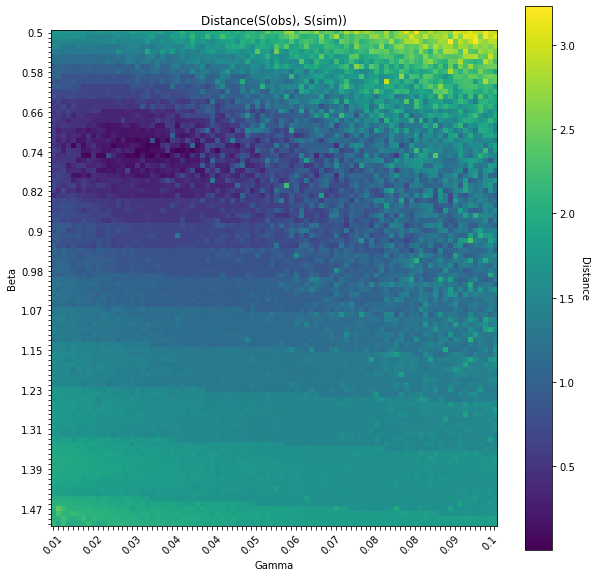

In [33]:
dist_mat, betas, gammas, summary_mat = get_distance_grid(beta_range, gamma_range, n_beta, n_gamma,\
                                                         distance_generalized, [BSI_max, BSI_max_t], bsi_obs[0], is_agg = False)

plot_heatmap(dist_mat, betas, gammas, title = "Distance(S(obs), S(sim))", cbar_label = "Distance", nth = 8) # synthetic observed data, aggregated


Same but aggregated:

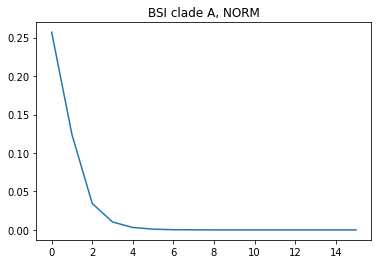

Iter: 0
Iter: 200
Iter: 400
Iter: 600
Iter: 800
Iter: 1000
Iter: 1200
Iter: 1400
Iter: 1600
Iter: 1800
Iter: 2000
Iter: 2200
Iter: 2400
Iter: 2600
Iter: 2800
Iter: 3000
Iter: 3200
Iter: 3400
Iter: 3600
Iter: 3800
Iter: 4000
Iter: 4200
Iter: 4400
Iter: 4600
Iter: 4800
Iter: 5000
Iter: 5200
Iter: 5400
Iter: 5600
Iter: 5800
Iter: 6000
Iter: 6200
Iter: 6400
Iter: 6600
Iter: 6800
Iter: 7000
Iter: 7200
Iter: 7400
Iter: 7600
Iter: 7800
Iter: 8000
Iter: 8200
Iter: 8400
Iter: 8600
Iter: 8800
Warning! SD is zero. Summary index: 1


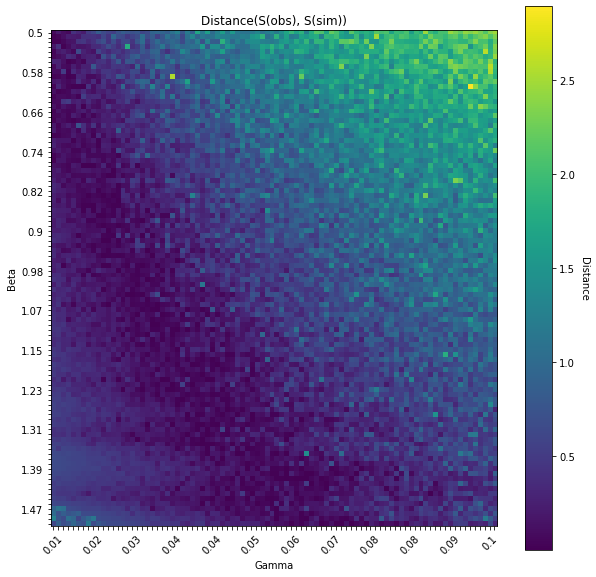

In [39]:
pop_size = 100000
n_weeks = 832
clade = "A"

bsi_pars = {"or_data": or_data, "clade": clade, "dataset": "NORM", "theta_c":1, "theta_bsi":0.3}
bsi_obs = SIR_and_BSI_simulator(np.array([0.735]), np.array([0.0223]), nt = n_weeks, N = pop_size,\
                                bsi_pars = bsi_pars, is_prop = True,\
                                is_agg = True, time_period = 52, batch_size = 1, random_state = None)#.flatten()
 
# Plot the synthetic observed data:
plt.plot(bsi_obs[0])
dataset = bsi_pars["dataset"]
plt.title(f"BSI clade {clade}, {dataset}")

plt.show()

# dimensions of the grid to simulate
n_beta = 100
n_gamma = 90

beta_range = (0.5, 1.5) # range of beta values to simulate
gamma_range = (0.0125, 0.1) # range of gamma values to simulate

dist_mat, betas, gammas, summary_mat = get_distance_grid(beta_range, gamma_range, n_beta, n_gamma,\
                                                         distance_generalized, [BSI_max, BSI_max_t], bsi_obs[0], is_agg = True)

plot_heatmap(dist_mat, betas, gammas, title = "Distance(S(obs), S(sim))", cbar_label = "Distance", nth = 8) # synthetic observed data, aggregated


# hetkinen mitenkäs tämä osuus on yli 400 prosenttia? A: väärä funktio aggregoinnissa :)

# Distance matrix between real observed data and simulations

Previously, synthetic data was used as the "observed" data. This time, we compare real and simulated data.

Note that real data has less data points than observed data and these data points are yearly observations instead of weekly ones. We need aggregate the simulated data to match the yearly observed data. Or alternatively, augment the observed data to be weekly. Or simply use the summaries, and not force the simulated and observed sequences to be the same length (here, the different time scales need to be taken into account though).


In [248]:
# Get the observed data

from cluster.scripts.load_data import *
obs_data = "NORM"
clade = "A"

if obs_data == "NORM":
    bsi_obs_data = get_obs_BSI(df = norm_data, clade = clade, is_prop = True)
else:
    bsi_obs_data = get_obs_BSI(df = bsac_data, clade = clade, is_prop = True)

print(bsi_obs_data)

2002    0.024096
2003    0.000000
2004    0.008000
2005    0.000000
2006    0.023622
2007    0.007143
2008    0.018868
2009    0.010417
2010    0.025510
2011    0.013514
2012    0.039711
2013    0.047059
2014    0.041509
2015    0.013201
2016    0.026667
2017    0.025352
Name: year, dtype: float64


In [249]:
print(BSI_max_t(bsi_obs_data)) # year 2013, 11 years from beginning (2002)
print(BSI_max(bsi_obs_data)) # max proportion of cases
print(len(bsi_obs_data))

11
0.047058823529411764
16


[4.25527614e-05 8.71444755e-06 1.78356894e-06 3.64994476e-07
 7.46915896e-08 1.52846277e-08 3.12778988e-09 6.40059253e-10
 1.30979332e-10 2.68031204e-11 5.48489027e-12 1.12240742e-12
 2.29685255e-13 4.70019310e-14 9.61829929e-15 1.96825278e-15]
16
0
4.2552761446857656e-05


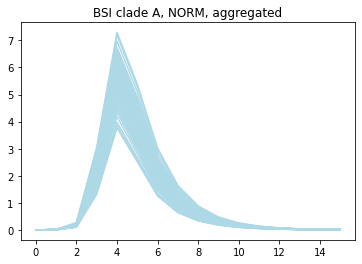

In [250]:
# aggregate simulated data:
n_weeks = 16*52
test_bsi_obs = SIR_and_BSI_simulator(0.37, 0.4, nt = n_weeks, N = pop_size, bsi_pars = bsi_pars,\
                                is_prop = True, is_agg = True, time_period = 52, reparam = False,\
                                batch_size = 1, random_state = None)[0]
print(test_bsi_obs)
print(len(test_bsi_obs))

print(BSI_max_t(test_bsi_obs))
print(BSI_max(test_bsi_obs))

# Plot the aggregated synthetic observed data, with repetitions:
n_rep = 100
for i in range(0, n_rep):
    test_bsi_obs = SIR_and_BSI_simulator(0.07, 0.012, nt = n_weeks, N = pop_size, bsi_pars = bsi_pars,\
                                is_prop = True, is_agg = True, time_period = 52, reparam = False,\
                                batch_size = 1, random_state = None)[0]
    plt.plot(test_bsi_obs, color = "lightblue")
    dataset = bsi_pars["dataset"]
plt.title(f"BSI clade {clade}, {dataset}, aggregated")
plt.show()

# This figure shows that the odds ratio "conversion" does not impact the general shape of the BSI, simply adds some uncertainty.

In [253]:
# Grid simulation
# dimensions of the grid to simulate
n_beta = 100
n_gamma = 90

beta_range = (0.01, 0.7) # range of beta values to simulate; has to be large enough to find the small distance areas,
# which can then be used to refine this range further. And used as values for synthetic data.
gamma_range = (0.0125, 0.5) # range of gamma values to simulate

dist_mat, betas, gammas, delta_S1_mat, delta_S2_mat = get_distance_grid(beta_range, gamma_range, n_beta, n_gamma, bsi_obs_data, is_agg = True)

# plottaa summaryitä näistä pisteistä: erikseen ja yhdessä molemmat

Iter: 0
Iter: 200
Iter: 400
Iter: 600
Iter: 800
Iter: 1000
Iter: 1200
Iter: 1400
Iter: 1600
Iter: 1800
Iter: 2000
Iter: 2200
Iter: 2400
Iter: 2600
Iter: 2800
Iter: 3000
Iter: 3200
Iter: 3400
Iter: 3600
Iter: 3800
Iter: 4000
Iter: 4200
Iter: 4400
Iter: 4600
Iter: 4800
Iter: 5000
Iter: 5200
Iter: 5400
Iter: 5600
Iter: 5800
Iter: 6000
Iter: 6200
Iter: 6400
Iter: 6600
Iter: 6800
Iter: 7000
Iter: 7200
Iter: 7400
Iter: 7600
Iter: 7800
Iter: 8000
Iter: 8200
Iter: 8400
Iter: 8600
Iter: 8800
7.142869878980346
25.55871819947158


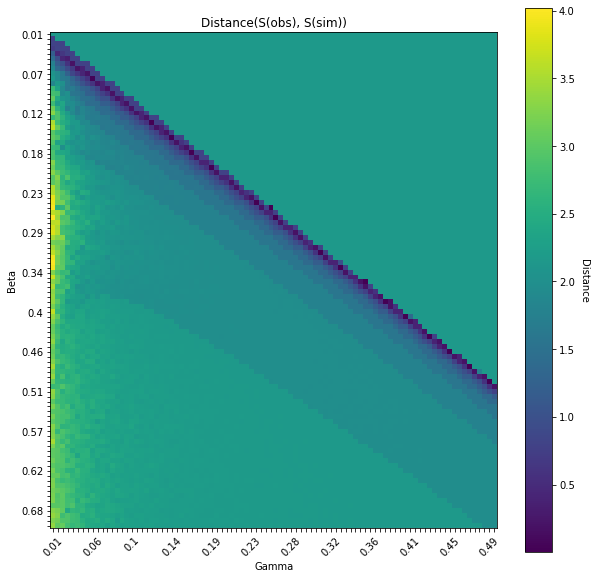

In [254]:
# Visualisation

plot_heatmap(dist_mat, betas, gammas, title = "Distance(S(obs), S(sim))", cbar_label = "Distance", nth = 8) # sus

5.844147252803547e-05 8.445930481348413e-05
0


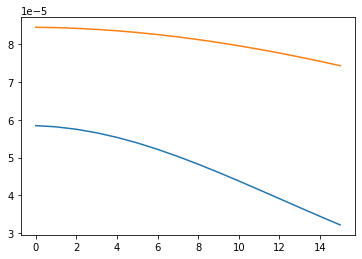

In [261]:
# Printing out some summaries when beta and gamma are the same:

testsim1 = SIR_and_BSI_simulator(0.45, 0.45, n_weeks, pop_size, bsi_pars,\
                                  is_prop = True, is_agg = True, time_period = 52, reparam = False,\
                                  batch_size = 1, random_state = None)[0]
testsim2 = SIR_and_BSI_simulator(0.2, 0.2, n_weeks, pop_size, bsi_pars,\
                                  is_prop = True, is_agg = True, time_period = 52, reparam = False,\
                                  batch_size = 1, random_state = None)[0]
print(BSI_max(testsim1), BSI_max(testsim2))

print(BSI_max_t(SIR_and_BSI_simulator(0.45, 0.45, n_weeks, pop_size, bsi_pars,\
                                  is_prop = True, is_agg = True, time_period = 52, reparam = False,\
                                  batch_size = 1, random_state = None)[0]))


# Plotting with same values:
# Plot the synthetic observed data:
plt.plot(testsim1)
plt.plot(testsim2)
plt.show()


### Notes
- Increasing the range of gamma here: distance is smallest when the parameters are the same. Does this make sense? I think yes, in the euclidean space.
- However, when simulating with for example $\beta = 0.37$ and $\gamma = 0.40$ the resulting figure is nowhere near the real data and its peaks.
    - TODO: with repetitions.
- **Q**: What if $\beta$ (transmission coefficient) and $\gamma$ (recovery rate) have different scales, as prior knowledge would suggest (time to clearance of colonization from a previous study?
- **Q**: Can $\beta$ and $\gamma$ have some correlation? I think not, since transmission and recovery intuitively seem like separate events.
- **Q**: Can different pairs of beta and gamma produce the same SIR figure? nope
- **Q**: Is euclidean distance the optimal distance metric here? I just chose it because it is easy. But can it lead to zeros even though we don't want it?
- **Q**: Is there too much uncertainty related to the odds ratio data? **A:** no based on repetitions of the same param combos.
- **Q**: Are there theoretical min/max values for $\beta$ and $\gamma$? **A:** beta,gamma>0.

**Different combos to test:**
- Different odds ratios
- Different time periods of interest
- Create a new summary k (how "fast" the proportion of BSI cases increases)
- Priors
- Distance metrix, summaries, summary combos...

**Literature review of the following topics:**
- Distance metrics in general and in infectious disease, focus on their properties and where they are applied
- Infectious disease modeling: more theoretical background on the relationship between beta and gamma.

**TODO**
- Test only the max BSI distance metric or only the time to max peak distance metric.
- Test BSI_max summary with BSI_var summary - same scale.

## Materials for visualisation
- Creating a heatmap: https://matplotlib.org/stable/gallery/images_contours_and_fields/image_annotated_heatmap.html
- "Smoothing" the heatmap: https://matplotlib.org/stable/gallery/images_contours_and_fields/interpolation_methods.html
